In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = ('/content/drive/MyDrive/Dataset/Wine Quality - Wine Quality.csv')
wine_quality = pd.read_csv(path)
wine_quality.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
wine_quality.shape

(6497, 13)

In [ ]:
#Checking for null values
wine_quality.isnull()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,False,False,False,False,False,False,False,False,False,False,False,False,False
6493,False,False,False,False,False,False,False,False,False,False,True,False,False
6494,False,False,False,False,False,False,False,False,False,False,False,False,False
6495,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
wine_quality.isnull().sum()

,0
type,0
fixed acidity,18
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
#Inputting values into null
wine_quality.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
wine_quality['fixed acidity'].isnull().sum()

18

In [ ]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='mean')

impute.fit(wine_quality[['fixed acidity']])

wine_quality['fixed acidity'] = impute.transform(wine_quality[['fixed acidity']])

In [ ]:
wine_quality['fixed acidity'].isnull().sum()

0

In [ ]:
#Handling categorical variables
wine_quality['type'].unique()

array(['white', 'red'], dtype=object)

In [ ]:
#Transforming
f_a = pd.get_dummies(wine_quality['fixed acidity'])
f_a.head()

,3.8,3.9,4.2,4.4,4.5,4.6,4.7,4.8,4.9,5.0,...,13.5,13.7,13.8,14.0,14.2,14.3,15.0,15.5,15.6,15.9
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Feature scaling
from sklearn.preprocessing import MinMaxScaler

MM_scaler = MinMaxScaler()

columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH','sulphates','alcohol', 'quality']
wine_quality[columns] = MM_scaler.fit_transform(wine_quality[columns])

wine_quality.head(10)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942,0.5
1,white,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391,0.5
2,white,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348,0.5
3,white,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.5
4,white,0.280992,0.100000,0.192771,0.121166,0.081395,0.159722,0.414747,0.163678,0.364341,0.101124,0.275362,0.5
5,white,0.355372,0.133333,0.240964,0.096626,0.068106,0.100694,0.209677,0.154039,0.418605,0.123596,0.304348,0.5
6,white,0.198347,0.160000,0.096386,0.098160,0.059801,0.100694,0.299539,0.150183,0.356589,0.140449,0.231884,0.5
7,white,0.264463,0.126667,0.216867,0.308282,0.059801,0.152778,0.377880,0.267785,0.217054,0.129213,0.115942,0.5
8,white,0.206612,0.146667,0.204819,0.015337,0.066445,0.045139,0.290323,0.132832,0.449612,0.151685,0.217391,0.5
9,white,0.355372,0.093333,0.259036,0.013804,0.058140,0.093750,0.283410,0.128976,0.387597,0.129213,0.434783,0.5


In [ ]:
#Correlation
column = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH','sulphates','alcohol']

wine_quality_correlation = wine_quality[column].corr()
print(wine_quality_correlation)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.220074     0.323130   
volatile acidity           0.220074          1.000000    -0.378061   
citric acid                0.323130         -0.378061     1.000000   
residual sugar            -0.112948         -0.196702     0.142486   
chlorides                  0.298235          0.377167     0.039315   
free sulfur dioxide       -0.283360         -0.353230     0.133437   
total sulfur dioxide      -0.329721         -0.414928     0.195218   
density                    0.458286          0.271193     0.096320   
pH                        -0.251342          0.260660    -0.328689   
sulphates                  0.299847          0.225476     0.057613   
alcohol                   -0.095215         -0.038248    -0.010433   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity              -0.112948   0.298235            -0.283360   
volatile acidit

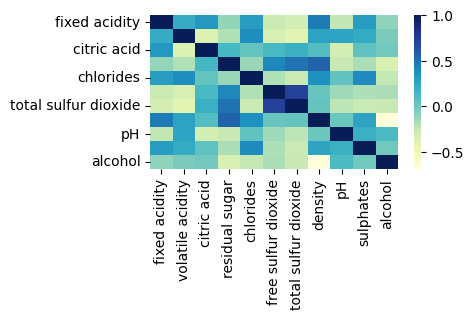

In [ ]:
#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
sns.heatmap(wine_quality_correlation, cmap='YlGnBu')
plt.show()

In [ ]:
import numpy as np


X = np.linspace(0, 100, 50)
delta = np.random.uniform(-10, 10, X.size)
Y = 0.5*X + 3 + delta

In [ ]:
import pandas as pd

dataset = pd.read_csv('/content/drive/MyDrive/Dataset/Wine Quality - Wine Quality.csv')
dataset.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
dataset = pd.get_dummies(wine_quality, columns=['type'], drop_first=True)

In [ ]:
x = dataset.drop('quality', axis=1).values
y = dataset['quality'].values

In [ ]:
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

In [ ]:
from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = .3, random_state = 0)
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(xTrain, yTrain)
yPrediction = clf.predict(xTest)
yPrediction

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
plt.scatter(xTrain, yTrain, color = 'red')
plt.plot(xTrain, clf.predict(xTrain), color = 'blue')−1nylog(11+e−(mx+b))+(1−y)log(1−11+e−(mx+b))

The rest of the procedure is exactly the same.
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [ ]:
#Dependencies for logistic regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [ ]:
#Splitting the data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Training the model
model = LogisticRegression()
model.fit(x_train, y_train) #Training the model
predictions = model.predict(x_test)
print(predictions)# printing predictions

In [ ]:
print(accuracy_score(y_test, predictions))